In [9]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math
import random

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device.type} device")

# Reproducibility
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
np.random.seed(seed)
random.seed(seed)

torch.backends.cudnn.deterministic = False
torch.backends.cudnn.benchmark = True


Using cuda device


In [11]:
def generate_sine_data(num_points=2000):
    x = np.arange(num_points)
    data = np.sin(0.02 * x) + 0.1 * np.random.randn(num_points)
    return torch.tensor(data, dtype=torch.float32)

In [12]:
sequence_length = 20
batch_size = 64

data = generate_sine_data()
train_size = int(0.8 * len(data))

train_data = data[:train_size]
test_data  = data[train_size:]

mean = train_data.mean()
std = train_data.std()

train_data = (train_data - mean) / std
test_data  = (test_data  - mean) / std

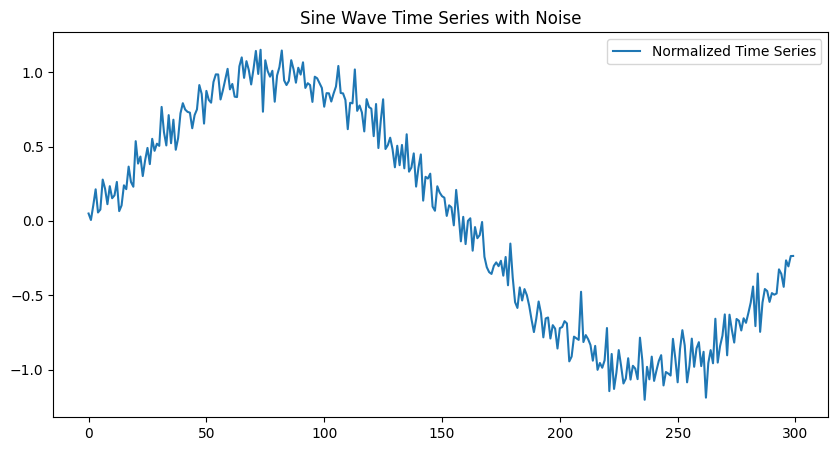

In [13]:
from matplotlib import pyplot as plt 
plt.figure(figsize=(10 , 5))
plt.plot(data[:300], label="Normalized Time Series")
plt.title("Sine Wave Time Series with Noise")
plt.legend()
plt.show()

In [14]:
class TimeSeriesDataset(Dataset):
    def __init__(self, data, seq_length):
        self.data = data
        self.seq_length = seq_length

    def __len__(self):
        return len(self.data) - self.seq_length

    def __getitem__(self, idx):
        x = self.data[idx:idx+self.seq_length]
        y = self.data[idx+self.seq_length]
        return x.unsqueeze(-1), y.unsqueeze(-1)


In [15]:
train_dataset = TimeSeriesDataset(train_data, sequence_length)
test_dataset  = TimeSeriesDataset(test_data, sequence_length)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False) # shuffle = False because bad for foracasting continuation 
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


In [36]:
X , y = next(iter(train_loader))
X.shape, y.shape

(torch.Size([64, 20, 1]), torch.Size([64, 1]))

In [16]:
class LSTM_Model(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        out = self.fc(last_hidden)     # (batch, 1)
        return out


In [17]:
def r2_score_torch(preds, targets):
    """
    preds, targets: shape (N, 1)
    """
    targets_mean = torch.mean(targets)
    ss_tot = torch.sum((targets - targets_mean) ** 2)
    ss_res = torch.sum((targets - preds) ** 2)

    r2 = 1 - ss_res / (ss_tot + 1e-8)
    return r2.item()


zero_grad → forward → loss → backward → clip → step

In [18]:
def train(dataloader, model, loss_fn, optimizer, device):
    model.train()
    total_loss = 0.0
    all_preds = []
    all_targets = []

    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)

        optimizer.zero_grad()
        preds = model(X)
        loss = loss_fn(preds, y)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        all_preds.append(preds.detach().cpu())
        all_targets.append(y.detach().cpu())

        if batch % 100 == 0:
            print(f"loss: {loss.item():.6f}")

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    avg_loss = total_loss / len(dataloader)
    r2 = r2_score_torch(all_preds, all_targets)

    return avg_loss, r2


In [19]:
def test(dataloader, model, loss_fn, device):
    model.eval()
    test_loss = 0.0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            preds = model(X)
            loss = loss_fn(preds, y)

            test_loss += loss.item()
            all_preds.append(preds)
            all_targets.append(y)

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    avg_loss = test_loss / len(dataloader)
    r2 = r2_score_torch(all_preds, all_targets)

    print(
        f"Test Metrics:\n"
        f" R2 Score: {r2:.4f}\n"
        f" Avg loss: {avg_loss:.6f}"
    )

    return avg_loss, r2


In [20]:
epochs = 40
lr = 3e-4
model = LSTM_Model().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
loss_fn = nn.MSELoss()

In [21]:
train_losses, train_r2s = [], []
test_losses, test_r2s = [], []

best_r2 = -float("inf")

for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}\n-------------------------------")

    tr_loss, tr_r2 = train(
        train_loader, model, loss_fn, optimizer, device
    )
    te_loss, te_r2 = test(
        test_loader, model, loss_fn, device
    )

    train_losses.append(tr_loss)
    train_r2s.append(tr_r2)
    test_losses.append(te_loss)
    test_r2s.append(te_r2)

    if te_r2 > best_r2:
        best_r2 = te_r2
        torch.save(model.state_dict(), "LSTM_sequence.pth")

print("Done")


Epoch 1
-------------------------------
loss: 1.148032
Test Metrics:
 R2 Score: 0.1344
 Avg loss: 0.980780

Epoch 2
-------------------------------
loss: 1.010504
Test Metrics:
 R2 Score: 0.3037
 Avg loss: 0.789075

Epoch 3
-------------------------------
loss: 0.838306
Test Metrics:
 R2 Score: 0.6476
 Avg loss: 0.399942

Epoch 4
-------------------------------
loss: 0.491675
Test Metrics:
 R2 Score: 0.9299
 Avg loss: 0.078947

Epoch 5
-------------------------------
loss: 0.052932
Test Metrics:
 R2 Score: 0.9468
 Avg loss: 0.059768

Epoch 6
-------------------------------
loss: 0.040569
Test Metrics:
 R2 Score: 0.9525
 Avg loss: 0.053487

Epoch 7
-------------------------------
loss: 0.045003
Test Metrics:
 R2 Score: 0.9578
 Avg loss: 0.047454

Epoch 8
-------------------------------
loss: 0.039325
Test Metrics:
 R2 Score: 0.9609
 Avg loss: 0.043930

Epoch 9
-------------------------------
loss: 0.039970
Test Metrics:
 R2 Score: 0.9635
 Avg loss: 0.041022

Epoch 10
------------------

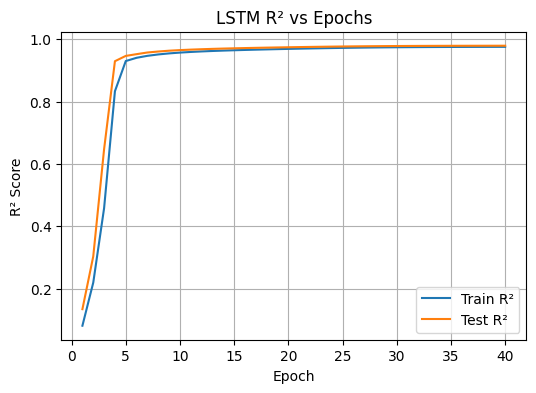

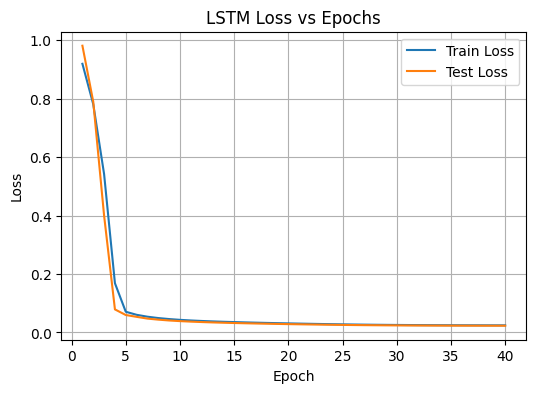

In [22]:
from matplotlib import pyplot as plt

epochs_range = range(1, len(train_losses) + 1)


plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_r2s, label="Train R²")
plt.plot(epochs_range, test_r2s, label="Test R²")
plt.xlabel("Epoch")
plt.ylabel("R² Score")
plt.title("LSTM R² vs Epochs")
plt.legend()
plt.grid(True)

plt.figure(figsize=(6,4))
plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, test_losses, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Loss vs Epochs")
plt.legend()
plt.grid(True)
plt.show()
